In [16]:
from torch.utils.data import Dataset, DataLoader, Subset
import rasterio
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import os, random, warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
print("Libraries loaded.")


Libraries loaded.


In [17]:
IMAGE_DIR = "/kaggle/input/datasets/petermoawad/satalite/data-20260926T092652Z-1-001/data/images"
LABEL_DIR = "/kaggle/input/datasets/petermoawad/satalite/data-20260926T092652Z-1-001/data/labels"

def read_tif(path):
    """Read a multi-band GeoTIFF -> float32 (C,H,W); NaN/Inf (nodata) -> 0."""
    with rasterio.open(path) as src:
        return np.nan_to_num(src.read().astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

def load_mask(path):
    """Read a label PNG -> 2-D array (H,W), robust to RGB/RGBA-saved masks."""
    m = np.array(Image.open(path))
    return m[..., 0] if m.ndim == 3 else m

# BUGFIX: pair images and labels BY FILENAME (stem), once, and use these two
# lists everywhere. Previously image_files / label_files were two independent
# sorted lists (paired by index) while WaterDataset built a third, different
# list -> split indices, normalisation stats, pos_weight and the Dataset could
# silently point at different samples (and mismatched image/label pairs).
def _stem(f): return os.path.splitext(f)[0]
img_map = {_stem(f): f for f in os.listdir(IMAGE_DIR) if f.lower().endswith((".tif", ".tiff"))}
lbl_map = {_stem(f): f for f in os.listdir(LABEL_DIR) if f.lower().endswith(".png")}
matched = sorted(img_map.keys() & lbl_map.keys())
assert len(matched) > 0, "No image/label pairs with matching filenames - check the folders."
print(f"images={len(img_map)}  labels={len(lbl_map)}  matched pairs={len(matched)}")
if len(matched) != len(img_map) or len(matched) != len(lbl_map):
    print("  WARNING: some files have no partner and are ignored.")
image_files = [img_map[k] for k in matched]
label_files = [lbl_map[k] for k in matched]

# ── Verify actual band metadata from the TIF file ────────────────────────────
sample_path = os.path.join(IMAGE_DIR, image_files[0])
with rasterio.open(sample_path) as src:
    n_bands, h, w = src.count, src.height, src.width
    band_descs     = src.descriptions          # may contain band names
    sample_img     = np.nan_to_num(src.read().astype(np.float32))

assert h % 16 == 0 and w % 16 == 0, f"U-Net (4 poolings) needs H,W divisible by 16, got {h}x{w}"
print("=" * 60)
print("  DATASET STRUCTURE")
print("=" * 60)
print(f"  Total samples : {len(image_files)}")
print(f"  Image shape   : ({n_bands}, {h}, {w})  [bands x H x W]")
print(f"  Label format  : PNG, binary (0=background, 255=water)")
print()
print("  Band metadata from TIF file:")
for i, d in enumerate(band_descs):
    mean_val = sample_img[i].mean()
    print(f"    ch{i:2d}: description={d!r:25s}  sample_mean={mean_val:.1f}")

# ── Class distribution (from all labels — for information only) ───────────────
water_px = total_px = 0
for fname in label_files:
    lbl = load_mask(os.path.join(LABEL_DIR, fname))
    water_px += int((lbl > 0).sum())
    total_px += int(lbl.size)

water_pct = 100 * water_px / total_px
print()
print(f"  Water pixels  : {water_px:,}  ({water_pct:.1f}%)")
print(f"  Background    : {total_px - water_px:,}  ({100 - water_pct:.1f}%)")
print(f"  Class imbalance ratio : {(100-water_pct)/water_pct:.1f}x")


images=306  labels=456  matched pairs=306
  DATASET STRUCTURE
  Total samples : 306
  Image shape   : (12, 128, 128)  [bands x H x W]
  Label format  : PNG, binary (0=background, 255=water)

  Band metadata from TIF file:
    ch 0: description=None                       sample_mean=174.1
    ch 1: description=None                       sample_mean=166.1
    ch 2: description=None                       sample_mean=326.9
    ch 3: description=None                       sample_mean=325.8
    ch 4: description=None                       sample_mean=1945.2
    ch 5: description=None                       sample_mean=1298.2
    ch 6: description=None                       sample_mean=678.8
    ch 7: description=None                       sample_mean=66.3
    ch 8: description=None                       sample_mean=247.0
    ch 9: description=None                       sample_mean=291.1
    ch10: description=None                       sample_mean=20.6
    ch11: description=None               

In [18]:
# ── Band Descriptions (Sentinel-2 MSI 12-band ordering assumed) ──────────────
# NOTE: actual band identity is verified above from rasterio metadata.
# Adjust GREEN_CH / NIR_CH / SWIR_CH if your dataset uses a different ordering.

BAND_INFO = [
    (0,  "B1  Coastal/Aerosol", "~443 nm",
     "Aerosol detection, shallow water penetration. "
     "Water is moderately reflective — used for clear/shallow water mapping."),
    (1,  "B2  Blue",            "~490 nm",
     "Deep water penetration. "
     "Used in true-colour RGB. Turbid water is brighter than clear water."),
    (2,  "B3  Green",           "~560 nm",
     "Chlorophyll reflection peak. KEY INPUT for NDWI & MNDWI. "
     "Water has moderate reflectance here."),
    (3,  "B4  Red",             "~665 nm",
     "Strong chlorophyll absorption. "
     "Water appears very dark — high contrast with dry soil."),
    (4,  "B5  Red-Edge",        "~705 nm",
     "Vegetation red-edge. Water absorbs almost completely."),
    (5,  "B6  Red-Edge",        "~740 nm",
     "Vegetation structure. Helps separate flooded vegetation from open water."),
    (6,  "B7  Red-Edge",        "~783 nm",
     "Near-IR transition. Water absorbs strongly."),
    (7,  "B8  NIR (broad)",     "~842 nm",
     "Water absorbs almost completely -> appears black. "
     "Core band for NDWI = (Green - NIR)/(Green + NIR)."),
    (8,  "B8A Narrow NIR",      "~865 nm",
     "Narrower NIR. Very high water absorption."),
    (9,  "B9  Water Vapour",    "~945 nm",
     "Atmospheric water-vapour; mainly used for atmospheric correction."),
    (10, "B11 SWIR-1",          "~1610 nm",
     "Water absorbs completely -> very dark. "
     "Core band for MNDWI = (Green - SWIR)/(Green + SWIR)."),
    (11, "B12 SWIR-2",          "~2190 nm",
     "Soil moisture & water content. Water absorbs completely."),
]

# ── Choose correct band indices for water indices ─────────────────────────────
# Based on Sentinel-2 B03 / B08 / B11 ordering (verified by metadata above).
# Change these if band_descs above shows a different order.
GREEN_CH = 2    # B3  Green  ~560 nm
NIR_CH   = 7    # B8  NIR    ~842 nm
SWIR_CH  = 10   # B11 SWIR-1 ~1610 nm

print("Band table:")
print(f"  {'ch':>3}  {'Name':20s}  {'Wavelength':10s}  Water effect")
print("  " + "-" * 70)
for ch, name, wl, desc in BAND_INFO:
    effect = desc.split(".")[0]
    marker = " <-- GREEN" if ch == GREEN_CH else " <-- NIR" if ch == NIR_CH else " <-- SWIR" if ch == SWIR_CH else ""
    print(f"  {ch:3d}  {name:20s}  {wl:10s}  {effect}{marker}")

# ── Validate index choices ────────────────────────────────────────────────────
# NDWI is meaningful only when Green reflectance > NIR reflectance for water
sample_ndwi = (sample_img[GREEN_CH] - sample_img[NIR_CH]) / (sample_img[GREEN_CH] + sample_img[NIR_CH] + 1e-8)
print(f"\n  Sample NDWI  stats: mean={sample_ndwi.mean():.3f}  "
      f"(positive = water detected, expected for water-rich scenes)")
sample_mndwi = (sample_img[GREEN_CH] - sample_img[SWIR_CH]) / (sample_img[GREEN_CH] + sample_img[SWIR_CH] + 1e-8)
print(f"  Sample MNDWI stats: mean={sample_mndwi.mean():.3f}")


# ── Sanity check: do the chosen bands actually separate water from land? ──────
# (replaces blind trust in the "assumed" Sentinel-2 ordering)
_lbl0 = load_mask(os.path.join(LABEL_DIR, label_files[0])) > 0
if _lbl0.any() and (~_lbl0).any():
    for nm, idx in [("NDWI", sample_ndwi), ("MNDWI", sample_mndwi)]:
        w_mean, l_mean = idx[_lbl0].mean(), idx[~_lbl0].mean()
        flag = "OK" if w_mean > l_mean else "!! WATER NOT HIGHER THAN LAND - band indices are probably wrong"
        print(f"  {nm}: water={w_mean:.3f}  land={l_mean:.3f}  -> {flag}")
else:
    print("  (first sample has only one class - sanity check skipped; try another sample)")

Band table:
   ch  Name                  Wavelength  Water effect
  ----------------------------------------------------------------------
    0  B1  Coastal/Aerosol   ~443 nm     Aerosol detection, shallow water penetration
    1  B2  Blue              ~490 nm     Deep water penetration
    2  B3  Green             ~560 nm     Chlorophyll reflection peak <-- GREEN
    3  B4  Red               ~665 nm     Strong chlorophyll absorption
    4  B5  Red-Edge          ~705 nm     Vegetation red-edge
    5  B6  Red-Edge          ~740 nm     Vegetation structure
    6  B7  Red-Edge          ~783 nm     Near-IR transition
    7  B8  NIR (broad)       ~842 nm     Water absorbs almost completely -> appears black <-- NIR
    8  B8A Narrow NIR        ~865 nm     Narrower NIR
    9  B9  Water Vapour      ~945 nm     Atmospheric water-vapour; mainly used for atmospheric correction
   10  B11 SWIR-1            ~1610 nm    Water absorbs completely -> very dark <-- SWIR
   11  B12 SWIR-2            ~21

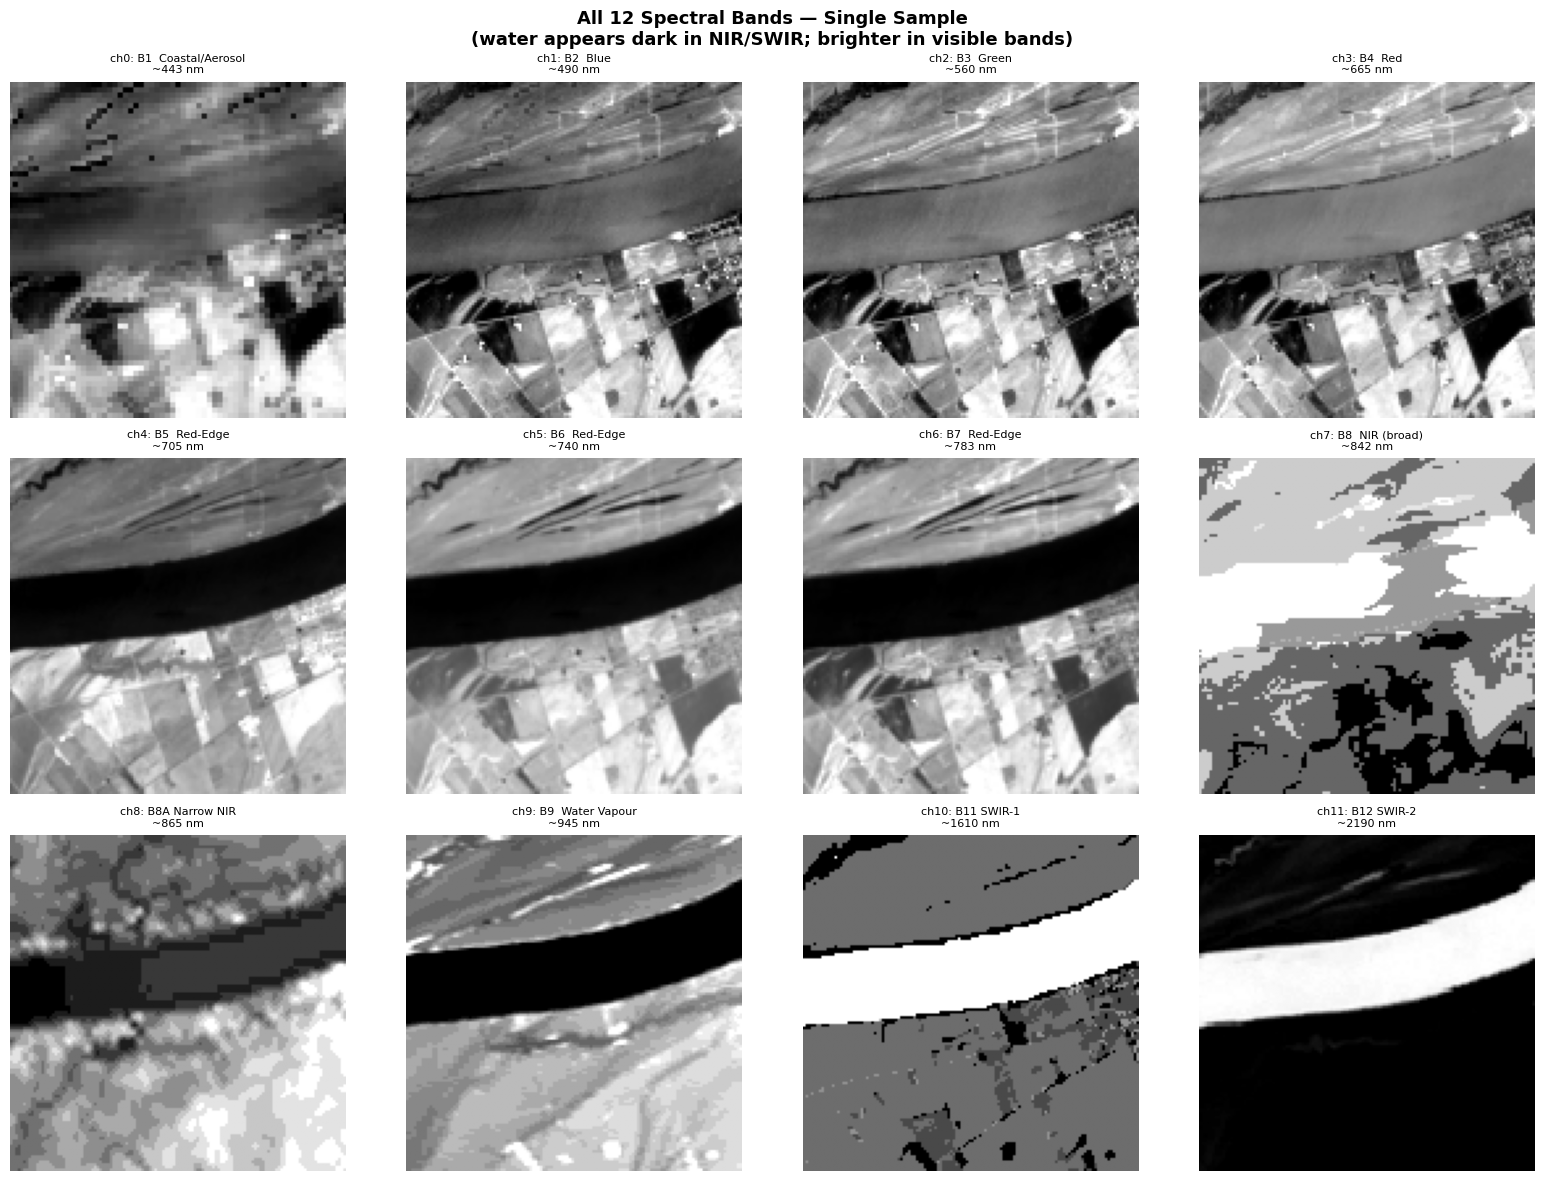

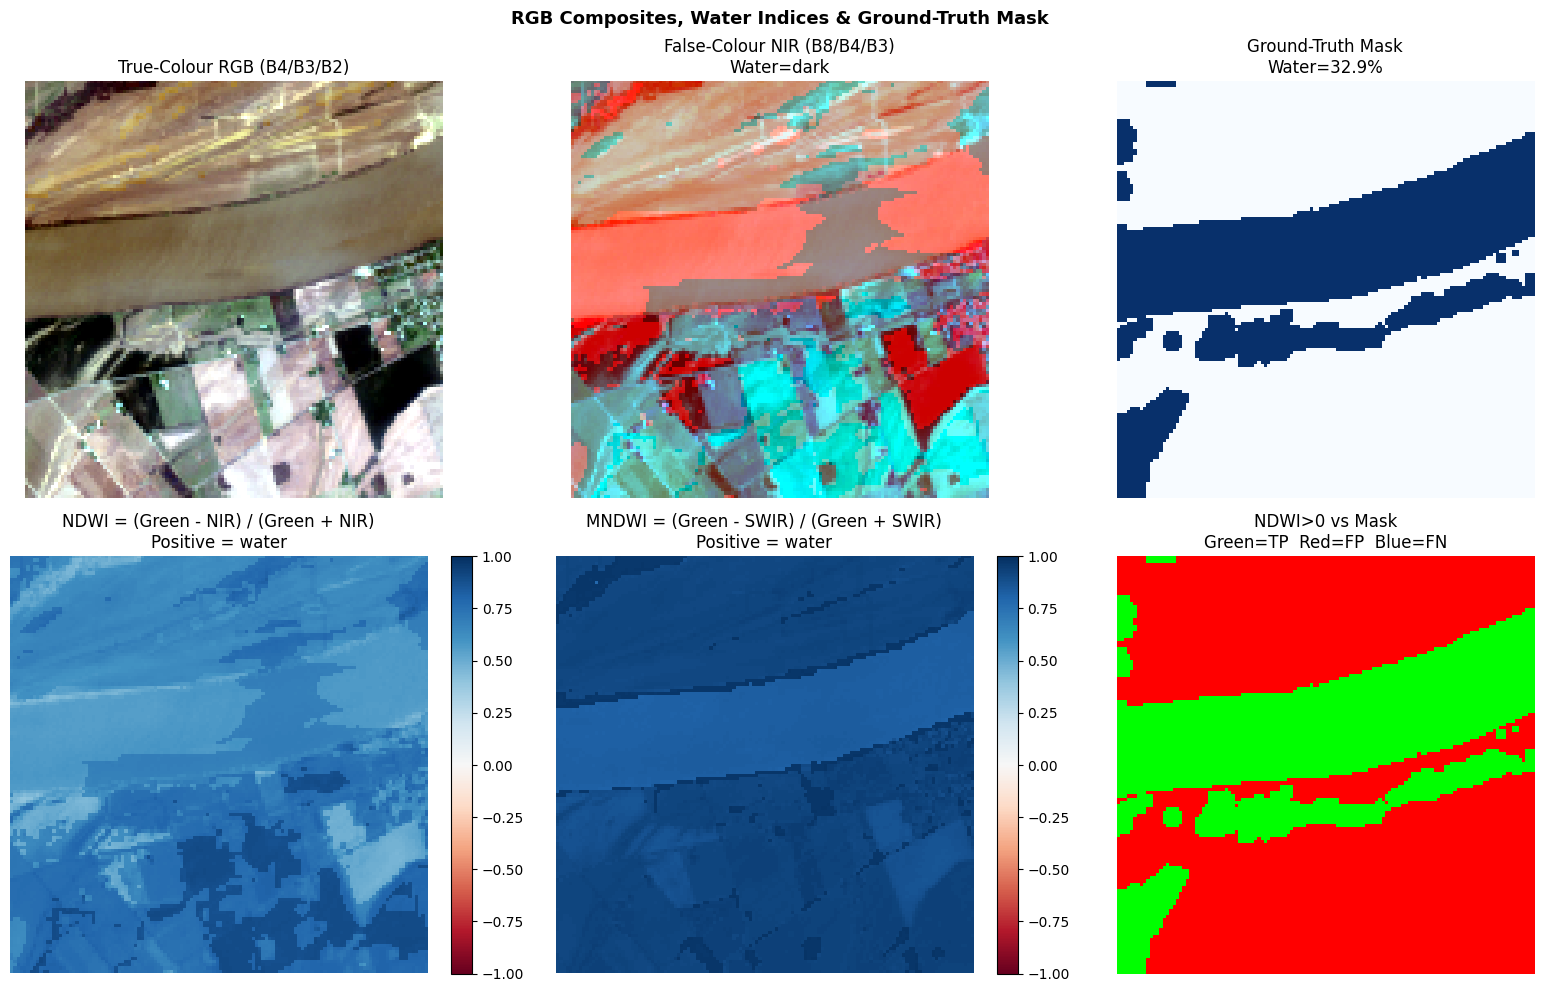

Visualisations saved.


In [19]:
def norm_display(band, lo=2, hi=98):
    lo_v, hi_v = np.percentile(band, lo), np.percentile(band, hi)
    return np.clip((band - lo_v) / (hi_v - lo_v + 1e-8), 0, 1)

mid = len(image_files) // 2
with rasterio.open(os.path.join(IMAGE_DIR, image_files[mid])) as sr:
    viz_img = sr.read().astype(np.float32)
viz_lbl = (np.array(Image.open(os.path.join(LABEL_DIR, label_files[mid]))) > 0).astype(np.float32)

# ── (A) All 12 spectral bands ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("All 12 Spectral Bands — Single Sample\n"
             "(water appears dark in NIR/SWIR; brighter in visible bands)",
             fontsize=13, fontweight="bold")
for c, ax in enumerate(axes.flat):
    ch, name, wl, _ = BAND_INFO[c]
    ax.imshow(norm_display(viz_img[c]), cmap="gray")
    ax.set_title(f"ch{c}: {name}\n{wl}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig("bands_12.png", dpi=150, bbox_inches="tight")
plt.show()

# ── (B) Composites + Water indices + Mask ──────────────────────────────────
ndwi_v  = (viz_img[GREEN_CH] - viz_img[NIR_CH])  / (viz_img[GREEN_CH] + viz_img[NIR_CH]  + 1e-8)
mndwi_v = (viz_img[GREEN_CH] - viz_img[SWIR_CH]) / (viz_img[GREEN_CH] + viz_img[SWIR_CH] + 1e-8)

rgb = np.stack([norm_display(viz_img[3]), norm_display(viz_img[2]), norm_display(viz_img[1])], -1)
fc  = np.stack([norm_display(viz_img[7]), norm_display(viz_img[3]), norm_display(viz_img[2])], -1)

ndwi_pred = (ndwi_v > 0).astype(np.float32)
overlap   = np.zeros((*ndwi_pred.shape, 3))
overlap[..., 0] = (ndwi_pred == 1) & (viz_lbl == 0)
overlap[..., 1] = (ndwi_pred == 1) & (viz_lbl == 1)
overlap[..., 2] = (ndwi_pred == 0) & (viz_lbl == 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("RGB Composites, Water Indices & Ground-Truth Mask", fontsize=13, fontweight="bold")

axes[0,0].imshow(rgb);         axes[0,0].set_title("True-Colour RGB (B4/B3/B2)"); axes[0,0].axis("off")
axes[0,1].imshow(fc);          axes[0,1].set_title("False-Colour NIR (B8/B4/B3)\nWater=dark"); axes[0,1].axis("off")
axes[0,2].imshow(viz_lbl, cmap="Blues")
axes[0,2].set_title(f"Ground-Truth Mask\nWater={viz_lbl.mean()*100:.1f}%"); axes[0,2].axis("off")

im1 = axes[1,0].imshow(ndwi_v,  cmap="RdBu", vmin=-1, vmax=1)
axes[1,0].set_title("NDWI = (Green - NIR) / (Green + NIR)\nPositive = water"); axes[1,0].axis("off")
plt.colorbar(im1, ax=axes[1,0], fraction=0.046)

im2 = axes[1,1].imshow(mndwi_v, cmap="RdBu", vmin=-1, vmax=1)
axes[1,1].set_title("MNDWI = (Green - SWIR) / (Green + SWIR)\nPositive = water"); axes[1,1].axis("off")
plt.colorbar(im2, ax=axes[1,1], fraction=0.046)

axes[1,2].imshow(overlap)
axes[1,2].set_title("NDWI>0 vs Mask\nGreen=TP  Red=FP  Blue=FN"); axes[1,2].axis("off")

plt.tight_layout()
plt.savefig("composites_indices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisations saved.")


## Research: Multispectral Segmentation & U-Net Architecture

### Multispectral vs RGB

| | RGB | Multispectral (12-ch) |
|--|--|--|
| Channels | 3 | 12 |
| Wavelength | 400–700 nm | 443–2190 nm |
| Water signal | Weak | Strong (NIR/SWIR absorbed by water) |

**Why NIR/SWIR are key for water:**  
Water strongly absorbs near-infrared (NIR ~842 nm) and shortwave infrared (SWIR ~1610 nm), making water bodies appear nearly **black** — a strong discriminative signal absent from RGB.

**Feature Engineering — Water Indices:**
- **NDWI** = (Green − NIR) / (Green + NIR) → positive for water, negative for land
- **MNDWI** = (Green − SWIR) / (Green + SWIR) → better at separating water from built-up areas

Adding NDWI + MNDWI as two extra channels gives the model **pre-computed physics-based water features**.

---

### U-Net Architecture

```
Input (14, 128, 128)
    ↓ Encoder (×4 levels) — downsample, double channels
    ↓ Bottleneck
    ↑ Decoder (×4 levels) — upsample + skip connections from encoder
    ↓
Output (1, 128, 128)  →  sigmoid  →  binary water mask
```

**Residual U-Net (Final Model):** Adds residual connections within each encoder/decoder block.  
Each block: `output = ReLU(Conv-BN-ReLU-Conv-BN(x) + shortcut(x))`  
Benefits: better gradient flow, faster convergence, improved segmentation accuracy.

In [20]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits)
        inter = (p * targets).sum(dim=(2, 3))
        union = p.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        return 1 - ((2 * inter + self.smooth) / (union + self.smooth)).mean()

class CombinedLoss(nn.Module):
    def __init__(self, pos_weight=None, bce_w=0.5, dice_w=0.5):
        super().__init__()
        self.bce    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.dice   = DiceLoss()
        self.bce_w  = bce_w
        self.dice_w = dice_w
    def forward(self, logits, targets):
        return self.bce_w * self.bce(logits, targets) + self.dice_w * self.dice(logits, targets)

print("DiceLoss, CombinedLoss defined.")


DiceLoss, CombinedLoss defined.


In [21]:
def add_indices(img):
    """(12,H,W) -> (14,H,W): append NDWI and MNDWI as extra channels."""
    g, nir, swir = img[GREEN_CH], img[NIR_CH], img[SWIR_CH]
    ndwi  = (g - nir)  / (g + nir  + 1e-8)
    mndwi = (g - swir) / (g + swir + 1e-8)
    return np.concatenate([img, ndwi[None], mndwi[None]], axis=0).astype(np.float32)

class WaterDataset(Dataset):
    """Supports 12-channel (baseline) or 14-channel (+ NDWI/MNDWI) modes.
    Receives EXPLICIT, already-paired file lists (no directory re-scan), so the
    train/val/test split can never go out of sync with the data."""
    def __init__(self, image_dir, label_dir, image_files, label_files,
                 means, stds, augment=False, use_indices=False):
        assert len(image_files) == len(label_files)
        self.image_dir, self.label_dir = image_dir, label_dir
        self.image_files, self.label_files = list(image_files), list(label_files)
        self.augment     = augment
        self.use_indices = use_indices
        self.n_ch        = 14 if use_indices else 12
        self.means = np.asarray(means, dtype=np.float32)[:, None, None]
        self.stds  = np.asarray(stds,  dtype=np.float32)[:, None, None]
        assert self.means.shape[0] == self.n_ch, "means/stds length does not match channel count"

    def _augment(self, img, lbl):
        if random.random() > 0.5:
            img = np.flip(img, axis=2).copy(); lbl = np.flip(lbl, axis=2).copy()
        if random.random() > 0.5:
            img = np.flip(img, axis=1).copy(); lbl = np.flip(lbl, axis=1).copy()
        k = random.randint(0, 3)
        img = np.rot90(img, k=k, axes=(1, 2)).copy()
        lbl = np.rot90(lbl, k=k, axes=(1, 2)).copy()
        return img, lbl

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        img = read_tif(os.path.join(self.image_dir, self.image_files[idx]))   # (12, H, W)
        if self.use_indices:
            img = add_indices(img)                                            # (14, H, W)

        # Dataset-wise per-channel normalisation (stats from training set only)
        img = ((img - self.means) / (self.stds + 1e-8)).astype(np.float32)

        lbl = load_mask(os.path.join(self.label_dir, self.label_files[idx]))
        lbl = (lbl > 0).astype(np.float32)[None]                              # (1, H, W)

        if self.augment:
            img, lbl = self._augment(img, lbl)

        return torch.from_numpy(np.ascontiguousarray(img)), torch.from_numpy(np.ascontiguousarray(lbl))

print("WaterDataset defined (12-ch and 14-ch modes).")

WaterDataset defined (12-ch and 14-ch modes).


In [22]:
BATCH_SIZE = 16

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
seed_everything(42)

# ── Step 1: Reproducible split FIRST (before any statistics) ─────────────────
n          = len(image_files)          # = number of MATCHED image/label pairs
train_size = int(0.8 * n)
val_size   = int(0.1 * n)
test_size  = n - train_size - val_size

generator = torch.Generator().manual_seed(42)
indices   = torch.randperm(n, generator=generator).tolist()
train_idx = indices[:train_size]
val_idx   = indices[train_size : train_size + val_size]
test_idx  = indices[train_size + val_size :]

print(f"Split  train={train_size}  val={val_size}  test={test_size}")

# ── Step 2: Normalisation stats from TRAINING data only (no leakage) ─────────
# BUGFIX: running sums in float64 instead of concatenating every pixel of every
# training image (12+2 channels) into RAM - that can OOM on large datasets.
train_files = [image_files[i] for i in train_idx]
s1 = np.zeros(14, dtype=np.float64); s2 = np.zeros(14, dtype=np.float64); cnt = 0
for fname in train_files:
    full = add_indices(read_tif(os.path.join(IMAGE_DIR, fname)))     # (14,H,W)
    flat = full.reshape(14, -1).astype(np.float64)
    s1  += flat.sum(1); s2 += (flat ** 2).sum(1); cnt += flat.shape[1]
means14 = s1 / cnt
stds14  = np.sqrt(np.maximum(s2 / cnt - means14 ** 2, 0.0))
means12, stds12 = means14[:12], stds14[:12]

print("Training-set-only statistics computed.")
print(f"  12-ch: means in [{means12.min():.1f}, {means12.max():.1f}]")
print(f"  NDWI  mean={means14[12]:.4f}  MNDWI mean={means14[13]:.4f}")

# ── Step 3: pos_weight from training labels only ──────────────────────────────
water_px = total_px = 0
for i in train_idx:
    lbl = load_mask(os.path.join(LABEL_DIR, label_files[i]))
    water_px += int((lbl > 0).sum())
    total_px += int(lbl.size)
pos_weight = torch.tensor([(total_px - water_px) / (water_px + 1e-8)], dtype=torch.float32)
print(f"  pos_weight = {pos_weight.item():.2f}  (training-set class ratio)")

# ── Step 4: Datasets / DataLoaders built from the SAME paired lists ───────────
def make_loaders(means, stds, use_indices, batch=BATCH_SIZE):
    def ds(idx, augment):
        return WaterDataset(IMAGE_DIR, LABEL_DIR,
                            [image_files[i] for i in idx], [label_files[i] for i in idx],
                            means, stds, augment=augment, use_indices=use_indices)
    tr = DataLoader(ds(train_idx, True),  batch_size=batch, shuffle=True,  num_workers=2, pin_memory=True)
    vl = DataLoader(ds(val_idx,   False), batch_size=batch, shuffle=False, num_workers=2, pin_memory=True)
    te = DataLoader(ds(test_idx,  False), batch_size=batch, shuffle=False, num_workers=2, pin_memory=True)
    return tr, vl, te

train_loader_12, val_loader_12, test_loader_12 = make_loaders(means12, stds12, use_indices=False)
train_loader_14, val_loader_14, test_loader_14 = make_loaders(means14, stds14, use_indices=True)

print(f"12-ch loaders: train={len(train_loader_12.dataset)}  val={len(val_loader_12.dataset)}  test={len(test_loader_12.dataset)}")
print(f"14-ch loaders: same sizes with NDWI/MNDWI channels added")

Split  train=244  val=30  test=32
Training-set-only statistics computed.
  12-ch: means in [9.9, 2042.9]
  NDWI  mean=-19210.3269  MNDWI mean=-11505.7211
  pos_weight = 2.76  (training-set class ratio)
12-ch loaders: train=244  val=30  test=32
14-ch loaders: same sizes with NDWI/MNDWI channels added


In [23]:
# ── Baseline U-Net (12-channel, basic) ───────────────────────────────────────
class UNet(nn.Module):
    """Standard U-Net with 4 encoder-decoder levels.
    Baseline: input_channels=12.  Feature-Engineering run: input_channels=14."""
    def __init__(self, input_channels, output_channels=1):
        super().__init__()
        def conv_block(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
                nn.Conv2d(oc, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(inplace=True))

        self.enc1 = conv_block(input_channels, 64)
        self.enc2 = conv_block(64,  128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = conv_block(512, 1024)
        self.up1  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec1 = conv_block(1024, 512)
        self.up2  = nn.ConvTranspose2d(512,  256, 2, stride=2)
        self.dec2 = conv_block(512,  256)
        self.up3  = nn.ConvTranspose2d(256,  128, 2, stride=2)
        self.dec3 = conv_block(256,  128)
        self.up4  = nn.ConvTranspose2d(128,   64, 2, stride=2)
        self.dec4 = conv_block(128,   64)
        self.out  = nn.Conv2d(64, output_channels, 1)

    def forward(self, x):
        s1 = self.enc1(x);      x = self.pool(s1)
        s2 = self.enc2(x);      x = self.pool(s2)
        s3 = self.enc3(x);      x = self.pool(s3)
        s4 = self.enc4(x);      x = self.pool(s4)
        x  = self.bottleneck(x)
        x  = self.dec1(torch.cat([self.up1(x), s4], 1))
        x  = self.dec2(torch.cat([self.up2(x), s3], 1))
        x  = self.dec3(torch.cat([self.up3(x), s2], 1))
        x  = self.dec4(torch.cat([self.up4(x), s1], 1))
        return self.out(x)

print("UNet (Baseline) defined.")


UNet (Baseline) defined.


In [24]:
# ── Residual U-Net (14-channel, Final Model) ──────────────────────────────────
class ResidualBlock(nn.Module):
    """Conv block with residual (skip) connection within the block."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch))
        self.shortcut = (nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch))
                         if in_ch != out_ch else nn.Identity())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv(x) + self.shortcut(x))

class ResidualUNet(nn.Module):
    """U-Net where every conv block is replaced by a ResidualBlock.
    Benefits: better gradient flow, faster convergence (adds only the small 1x1 shortcut convs)."""
    def __init__(self, input_channels, output_channels=1):
        super().__init__()
        self.enc1 = ResidualBlock(input_channels, 64)
        self.enc2 = ResidualBlock(64,  128)
        self.enc3 = ResidualBlock(128, 256)
        self.enc4 = ResidualBlock(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ResidualBlock(512, 1024)
        self.up1  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec1 = ResidualBlock(1024, 512)
        self.up2  = nn.ConvTranspose2d(512,  256, 2, stride=2)
        self.dec2 = ResidualBlock(512,  256)
        self.up3  = nn.ConvTranspose2d(256,  128, 2, stride=2)
        self.dec3 = ResidualBlock(256,  128)
        self.up4  = nn.ConvTranspose2d(128,   64, 2, stride=2)
        self.dec4 = ResidualBlock(128,   64)
        self.out  = nn.Conv2d(64, output_channels, 1)

    def forward(self, x):
        s1 = self.enc1(x);      x = self.pool(s1)
        s2 = self.enc2(x);      x = self.pool(s2)
        s3 = self.enc3(x);      x = self.pool(s3)
        s4 = self.enc4(x);      x = self.pool(s4)
        x  = self.bottleneck(x)
        x  = self.dec1(torch.cat([self.up1(x), s4], 1))
        x  = self.dec2(torch.cat([self.up2(x), s3], 1))
        x  = self.dec3(torch.cat([self.up3(x), s2], 1))
        x  = self.dec4(torch.cat([self.up4(x), s1], 1))
        return self.out(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_b = UNet(12, 1);          _r = ResidualUNet(14, 1)
print(f"UNet(12,1)       params: {sum(p.numel() for p in _b.parameters()):,}")
print(f"ResidualUNet(14,1) params: {sum(p.numel() for p in _r.parameters()):,}")
del _b, _r
print(f"Device: {device}")


UNet(12,1)       params: 31,042,817
ResidualUNet(14,1) params: 32,443,393
Device: cuda


In [25]:
# Reusable training + evaluation functions 
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n_samples = 0.0, 0
    tp = fp = fn = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            out = model(imgs)
            # BUGFIX: weight by batch size so a smaller last batch isn't over-counted
            total_loss += criterion(out, masks).item() * imgs.size(0)
            n_samples  += imgs.size(0)
            pred = (torch.sigmoid(out) > 0.5).float()
            tp += (pred * masks).sum().item()
            fp += (pred * (1 - masks)).sum().item()
            fn += ((1 - pred) * masks).sum().item()
    iou  = tp / (tp + fp + fn + 1e-8)
    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    return {"loss": total_loss / n_samples, "iou": float(iou),
            "precision": float(prec), "recall": float(rec), "f1": float(f1)}

def train_model(model, train_loader, val_loader, name,
                epochs=100, lr=1e-4, patience=10, criterion=None, monitor="loss"):
    """criterion : any callable loss(logits, targets); default = BCE+Dice.
    monitor   : "loss" -> keep checkpoint with lowest val loss;
                "iou"  -> keep checkpoint with highest val IoU.
    Use monitor="iou" when COMPARING different losses (their loss values are not comparable)."""
    if criterion is None:
        criterion = CombinedLoss(pos_weight=pos_weight.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)
    sign = 1.0 if monitor == "loss" else -1.0      # scheduler/early-stop always minimise `score`

    history  = {"train_loss":[], "val_loss":[], "iou":[], "precision":[], "recall":[], "f1":[]}
    best_score = float("inf")
    no_improve = 0
    save_path  = f"{name}_best.pth"

    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), masks)
            loss.backward(); optimizer.step()
            t_loss += loss.item()
        avg_train = t_loss / len(train_loader)

        m = evaluate(model, val_loader, criterion, device)
        score = sign * m[monitor]
        scheduler.step(score)

        history["train_loss"].append(avg_train)
        history["val_loss"].append(m["loss"])
        history["iou"].append(m["iou"])
        history["precision"].append(m["precision"])
        history["recall"].append(m["recall"])
        history["f1"].append(m["f1"])

        if score < best_score:
            best_score = score
            no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            no_improve += 1

        lr_cur = optimizer.param_groups[0]["lr"]
        print(f"[{name}] E{epoch+1:03d}/{epochs} | lr={lr_cur:.1e} | "
              f"train={avg_train:.4f} val={m['loss']:.4f} | "
              f"IoU={m['iou']:.4f} F1={m['f1']:.4f}")

        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(torch.load(save_path, map_location=device))
    print(f"\n[{name}] Best val {monitor}: {sign * best_score:.4f}")
    return history, save_path

print("evaluate() and train_model() defined.")


evaluate() and train_model() defined.


In [26]:
# BASELINE: 12-channel standard U-Net
print("=" * 60)
print("  BASELINE — UNet(12, 1)  |  12 spectral bands")
print("=" * 60)

baseline_model = UNet(12, 1).to(device)
history_baseline, _ = train_model(
    baseline_model, train_loader_12, val_loader_12,
    name="baseline", epochs=100, lr=1e-4, patience=10)


  BASELINE — UNet(12, 1)  |  12 spectral bands
[baseline] E001/100 | lr=1.0e-04 | train=0.7011 val=0.7538 | IoU=0.6524 F1=0.7897
[baseline] E002/100 | lr=1.0e-04 | train=0.5614 val=0.5556 | IoU=0.6343 F1=0.7762
[baseline] E003/100 | lr=1.0e-04 | train=0.5506 val=0.5219 | IoU=0.6444 F1=0.7837
[baseline] E004/100 | lr=1.0e-04 | train=0.5417 val=0.5337 | IoU=0.5920 F1=0.7437
[baseline] E005/100 | lr=1.0e-04 | train=0.5319 val=0.5391 | IoU=0.5834 F1=0.7369
[baseline] E006/100 | lr=1.0e-04 | train=0.5171 val=0.5160 | IoU=0.5984 F1=0.7487
[baseline] E007/100 | lr=1.0e-04 | train=0.5116 val=0.5015 | IoU=0.6340 F1=0.7760
[baseline] E008/100 | lr=1.0e-04 | train=0.5035 val=0.5155 | IoU=0.5776 F1=0.7322
[baseline] E009/100 | lr=1.0e-04 | train=0.4961 val=0.4933 | IoU=0.6063 F1=0.7549
[baseline] E010/100 | lr=1.0e-04 | train=0.4983 val=0.5068 | IoU=0.6036 F1=0.7528
[baseline] E011/100 | lr=1.0e-04 | train=0.4882 val=0.4958 | IoU=0.6013 F1=0.7510
[baseline] E012/100 | lr=1.0e-04 | train=0.4719 val

In [27]:
# FEATURE ENGINEERING: 14-channel standard U-Net (12 bands + NDWI + MNDWI)
print("=" * 60)
print("  FEATURE ENG — UNet(14, 1)  |  12 bands + NDWI + MNDWI")
print("=" * 60)

fe_model = UNet(14, 1).to(device)
history_fe, _ = train_model(
    fe_model, train_loader_14, val_loader_14,
    name="fe_unet", epochs=100, lr=1e-4, patience=10)


  FEATURE ENG — UNet(14, 1)  |  12 bands + NDWI + MNDWI
[fe_unet] E001/100 | lr=1.0e-04 | train=0.7135 val=0.7518 | IoU=0.5895 F1=0.7418
[fe_unet] E002/100 | lr=1.0e-04 | train=0.5767 val=0.5439 | IoU=0.6301 F1=0.7731
[fe_unet] E003/100 | lr=1.0e-04 | train=0.5548 val=0.5260 | IoU=0.5965 F1=0.7473
[fe_unet] E004/100 | lr=1.0e-04 | train=0.5452 val=0.5106 | IoU=0.6566 F1=0.7927
[fe_unet] E005/100 | lr=1.0e-04 | train=0.5206 val=0.5044 | IoU=0.6328 F1=0.7751
[fe_unet] E006/100 | lr=1.0e-04 | train=0.5324 val=0.4864 | IoU=0.6351 F1=0.7769
[fe_unet] E007/100 | lr=1.0e-04 | train=0.5122 val=0.4998 | IoU=0.6304 F1=0.7733
[fe_unet] E008/100 | lr=1.0e-04 | train=0.5071 val=0.5289 | IoU=0.5703 F1=0.7264
[fe_unet] E009/100 | lr=1.0e-04 | train=0.4995 val=0.4885 | IoU=0.6744 F1=0.8056
[fe_unet] E010/100 | lr=1.0e-04 | train=0.4999 val=0.5166 | IoU=0.5747 F1=0.7299
[fe_unet] E011/100 | lr=1.0e-04 | train=0.5157 val=0.4701 | IoU=0.6680 F1=0.8010
[fe_unet] E012/100 | lr=1.0e-04 | train=0.4906 val=0.

In [28]:
# FEATURE ENGINEERING: 14-channel standard U-Net (12 bands + NDWI + MNDWI)
print("=" * 60)
print("  FEATURE ENG — UNet(14, 1)  |  12 bands + NDWI + MNDWI")
print("=" * 60)

fe_model = UNet(14, 1).to(device)
history_fe, _ = train_model(
    fe_model, train_loader_14, val_loader_14,
    name="fe_unet", epochs=100, lr=1e-4, patience=10)


  FEATURE ENG — UNet(14, 1)  |  12 bands + NDWI + MNDWI
[fe_unet] E001/100 | lr=1.0e-04 | train=0.6973 val=0.7550 | IoU=0.6318 F1=0.7743
[fe_unet] E002/100 | lr=1.0e-04 | train=0.5625 val=0.5333 | IoU=0.6676 F1=0.8007
[fe_unet] E003/100 | lr=1.0e-04 | train=0.5398 val=0.5269 | IoU=0.6548 F1=0.7914
[fe_unet] E004/100 | lr=1.0e-04 | train=0.5213 val=0.4990 | IoU=0.6369 F1=0.7782
[fe_unet] E005/100 | lr=1.0e-04 | train=0.5117 val=0.5349 | IoU=0.5726 F1=0.7282
[fe_unet] E006/100 | lr=1.0e-04 | train=0.5011 val=0.4902 | IoU=0.6570 F1=0.7930
[fe_unet] E007/100 | lr=1.0e-04 | train=0.4914 val=0.5344 | IoU=0.5517 F1=0.7111
[fe_unet] E008/100 | lr=1.0e-04 | train=0.5005 val=0.4982 | IoU=0.6293 F1=0.7725
[fe_unet] E009/100 | lr=1.0e-04 | train=0.4802 val=0.4865 | IoU=0.6638 F1=0.7979
[fe_unet] E010/100 | lr=1.0e-04 | train=0.4957 val=0.5225 | IoU=0.5582 F1=0.7164
[fe_unet] E011/100 | lr=1.0e-04 | train=0.4869 val=0.4778 | IoU=0.6582 F1=0.7939
[fe_unet] E012/100 | lr=1.0e-04 | train=0.4840 val=0.

In [29]:
# FINAL MODEL: 14-channel Residual U-Net (FE + Residual blocks)
print("=" * 60)
print("  FINAL — ResidualUNet(14, 1)  |  12 bands + NDWI + MNDWI + Residual blocks")
print("=" * 60)

final_model = ResidualUNet(14, 1).to(device)
history_final, _ = train_model(
    final_model, train_loader_14, val_loader_14,
    name="final_residual", epochs=100, lr=1e-4, patience=10)


  FINAL — ResidualUNet(14, 1)  |  12 bands + NDWI + MNDWI + Residual blocks
[final_residual] E001/100 | lr=1.0e-04 | train=0.6606 val=0.6723 | IoU=0.6623 F1=0.7969
[final_residual] E002/100 | lr=1.0e-04 | train=0.5244 val=0.5063 | IoU=0.6548 F1=0.7914
[final_residual] E003/100 | lr=1.0e-04 | train=0.5110 val=0.4799 | IoU=0.6261 F1=0.7701
[final_residual] E004/100 | lr=1.0e-04 | train=0.4923 val=0.4703 | IoU=0.6562 F1=0.7924
[final_residual] E005/100 | lr=1.0e-04 | train=0.4906 val=0.4762 | IoU=0.6580 F1=0.7937
[final_residual] E006/100 | lr=1.0e-04 | train=0.4913 val=0.4622 | IoU=0.6681 F1=0.8010
[final_residual] E007/100 | lr=1.0e-04 | train=0.4985 val=0.4783 | IoU=0.6173 F1=0.7633
[final_residual] E008/100 | lr=1.0e-04 | train=0.4665 val=0.4575 | IoU=0.6684 F1=0.8012
[final_residual] E009/100 | lr=1.0e-04 | train=0.4631 val=0.4355 | IoU=0.6601 F1=0.7952
[final_residual] E010/100 | lr=1.0e-04 | train=0.4599 val=0.4770 | IoU=0.5999 F1=0.7499
[final_residual] E011/100 | lr=1.0e-04 | tra

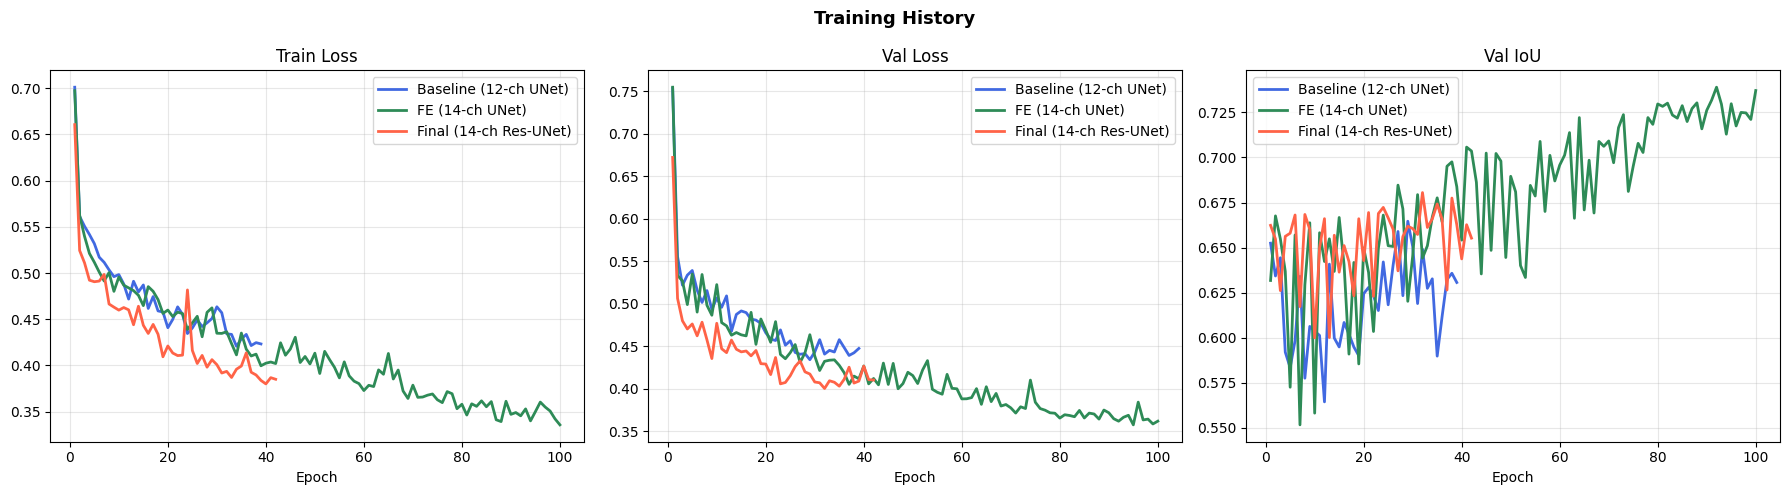

In [30]:
#  Training curves 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History", fontsize=13, fontweight="bold")

configs = [
    ("Baseline (12-ch UNet)",  history_baseline, "royalblue"),
    ("FE (14-ch UNet)",        history_fe,        "seagreen"),
    ("Final (14-ch Res-UNet)", history_final,     "tomato"),
]
for name, hist, color in configs:
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(ep, hist["train_loss"], label=name, color=color, linewidth=2)
    axes[1].plot(ep, hist["val_loss"],   label=name, color=color, linewidth=2)
    axes[2].plot(ep, hist["iou"],        label=name, color=color, linewidth=2)

for ax, title in zip(axes, ["Train Loss", "Val Loss", "Val IoU"]):
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


  Model                        Loss      IoU     Prec      Rec       F1
  Baseline (12-ch UNet)      0.4787   0.5839   0.6423   0.8653   0.7373
  FE (14-ch UNet)            0.4096   0.6494   0.6981   0.9029   0.7874
  Final (14-ch Res-UNet)     0.4481   0.6008   0.6421   0.9032   0.7506


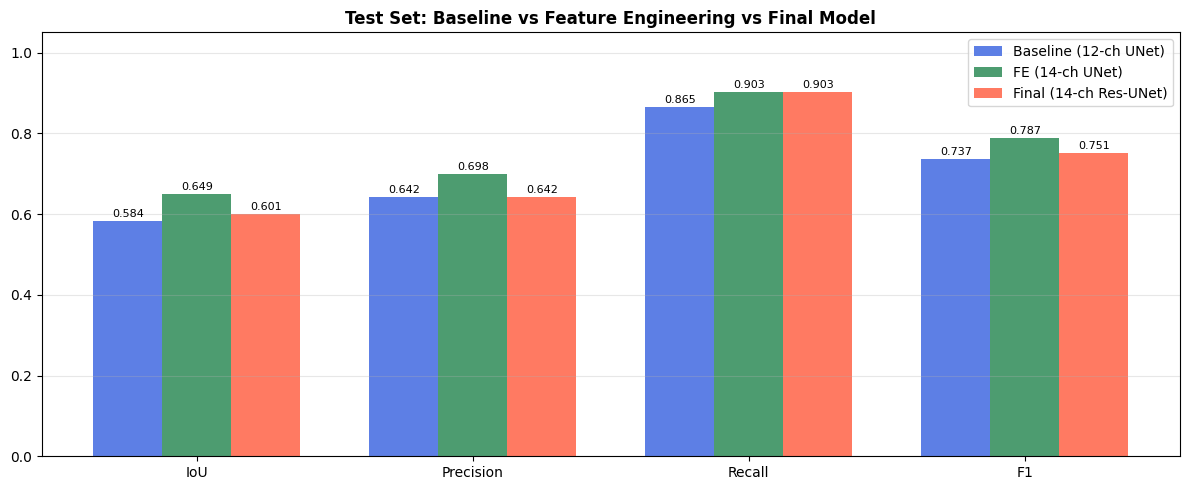

In [31]:
#  Test-set evaluation for all 3 models 
criterion_eval = CombinedLoss(pos_weight=pos_weight.to(device))

results = {
    "Baseline (12-ch UNet)":   evaluate(baseline_model, test_loader_12, criterion_eval, device),
    "FE (14-ch UNet)":         evaluate(fe_model,       test_loader_14, criterion_eval, device),
    "Final (14-ch Res-UNet)":  evaluate(final_model,    test_loader_14, criterion_eval, device),
}

print("=" * 72)
print(f"  {'Model':<25} {'Loss':>7}  {'IoU':>7}  {'Prec':>7}  {'Rec':>7}  {'F1':>7}")
print("=" * 72)
for name, m in results.items():
    print(f"  {name:<25} {m['loss']:7.4f}  {m['iou']:7.4f}  "
          f"{m['precision']:7.4f}  {m['recall']:7.4f}  {m['f1']:7.4f}")
print("=" * 72)

# Bar chart comparison
metrics = ["iou", "precision", "recall", "f1"]
x       = range(len(metrics))
width   = 0.25
colors  = ["royalblue", "seagreen", "tomato"]
labels  = list(results.keys())

fig, ax = plt.subplots(figsize=(12, 5))
for i, (lbl, m, clr) in enumerate(zip(labels, results.values(), colors)):
    vals = [m[k] for k in metrics]
    bars = ax.bar([xi + i*width for xi in x], vals, width, label=lbl, color=clr, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(["IoU", "Precision", "Recall", "F1"])
ax.set_ylim(0, 1.05)
ax.set_title("Test Set: Baseline vs Feature Engineering vs Final Model", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [32]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """Binary focal loss. alpha=0.5 -> no class re-weighting, only the (1-p_t)^gamma focusing term."""
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__(); self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = torch.exp(-bce)
        a_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (a_t * (1 - p_t) ** self.gamma * bce).mean()

class FocalDiceLoss(nn.Module):
    def __init__(self, focal_w=0.5, dice_w=0.5):
        super().__init__()
        self.focal, self.dice = FocalLoss(), DiceLoss()
        self.fw, self.dw = focal_w, dice_w
    def forward(self, logits, targets):
        return self.fw * self.focal(logits, targets) + self.dw * self.dice(logits, targets)

EXP_EPOCHS = 50
# Edit this dict to try other losses - name -> loss object
loss_experiments = {
    "dice":       DiceLoss(),
    "bce_dice":   CombinedLoss(pos_weight=pos_weight.to(device)),
    "focal_dice": FocalDiceLoss(),
}
print("Experiments:", list(loss_experiments))

Experiments: ['dice', 'bce_dice', 'focal_dice']


In [33]:
exp_models, exp_histories = {}, {}
for name, crit in loss_experiments.items():
    print("=" * 60); print(f"  LOSS EXPERIMENT: {name}  |  ResidualUNet(14,1)  |  {EXP_EPOCHS} epochs"); print("=" * 60)
    seed_everything(42)                                  # identical init & data order for every run
    model = ResidualUNet(14, 1).to(device)
    hist, _ = train_model(model, train_loader_14, val_loader_14, name=f"exp_{name}",
                          epochs=EXP_EPOCHS, lr=1e-4, patience=10, criterion=crit, monitor="iou")
    exp_models[name], exp_histories[name] = model, hist

  LOSS EXPERIMENT: dice  |  ResidualUNet(14,1)  |  50 epochs
[exp_dice] E001/50 | lr=1.0e-04 | train=0.6473 val=0.6622 | IoU=0.5436 F1=0.7044
[exp_dice] E002/50 | lr=1.0e-04 | train=0.5729 val=0.5835 | IoU=0.3766 F1=0.5472
[exp_dice] E003/50 | lr=1.0e-04 | train=0.5523 val=0.5542 | IoU=0.3731 F1=0.5435
[exp_dice] E004/50 | lr=1.0e-04 | train=0.5459 val=0.5288 | IoU=0.4510 F1=0.6217
[exp_dice] E005/50 | lr=1.0e-04 | train=0.5325 val=0.5277 | IoU=0.3978 F1=0.5692
[exp_dice] E006/50 | lr=1.0e-04 | train=0.5342 val=0.5228 | IoU=0.4096 F1=0.5811
[exp_dice] E007/50 | lr=5.0e-05 | train=0.5191 val=0.5240 | IoU=0.3874 F1=0.5584
[exp_dice] E008/50 | lr=5.0e-05 | train=0.5065 val=0.5049 | IoU=0.4255 F1=0.5970
[exp_dice] E009/50 | lr=5.0e-05 | train=0.4953 val=0.5150 | IoU=0.4134 F1=0.5850
[exp_dice] E010/50 | lr=5.0e-05 | train=0.4937 val=0.5028 | IoU=0.4316 F1=0.6029
[exp_dice] E011/50 | lr=5.0e-05 | train=0.4971 val=0.5020 | IoU=0.4169 F1=0.5884
  Early stopping at epoch 11

[exp_dice] Best va

  Loss                IoU     Prec      Rec       F1
  dice             0.4957   0.6018   0.7377   0.6628
  bce_dice         0.5711   0.6550   0.8169   0.7270
  focal_dice       0.6127   0.7363   0.7850   0.7598
Best on test IoU: focal_dice


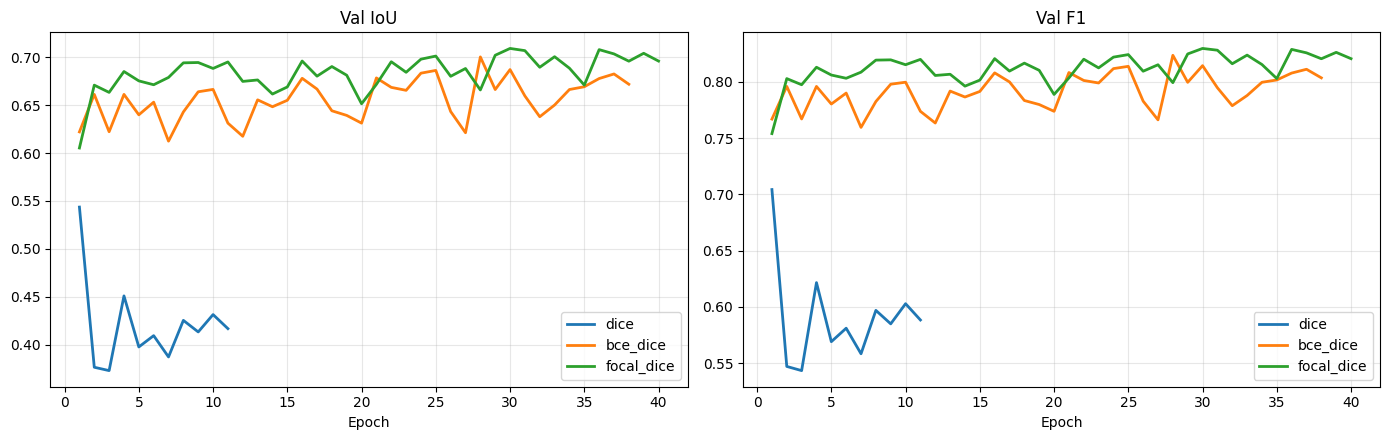

In [34]:
# ── Test-set comparison of the loss experiments ───────────────────────────────
exp_results = {n: evaluate(m, test_loader_14, loss_experiments[n], device) for n, m in exp_models.items()}

print("=" * 66)
print(f"  {'Loss':<14} {'IoU':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("=" * 66)
for n, r in exp_results.items():
    print(f"  {n:<14} {r['iou']:8.4f} {r['precision']:8.4f} {r['recall']:8.4f} {r['f1']:8.4f}")
print("=" * 66)
best_name = max(exp_results, key=lambda k: exp_results[k]["iou"])
print(f"Best on test IoU: {best_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for n, h in exp_histories.items():
    axes[0].plot(range(1, len(h["iou"]) + 1), h["iou"], label=n, linewidth=2)
    axes[1].plot(range(1, len(h["f1"]) + 1),  h["f1"],  label=n, linewidth=2)
for ax, t in zip(axes, ["Val IoU", "Val F1"]):
    ax.set_title(t); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("loss_experiments.png", dpi=150, bbox_inches="tight"); plt.show()

[focal_dice] test per-image IoU: mean=0.633  median=0.656  min=0.000  max=1.000


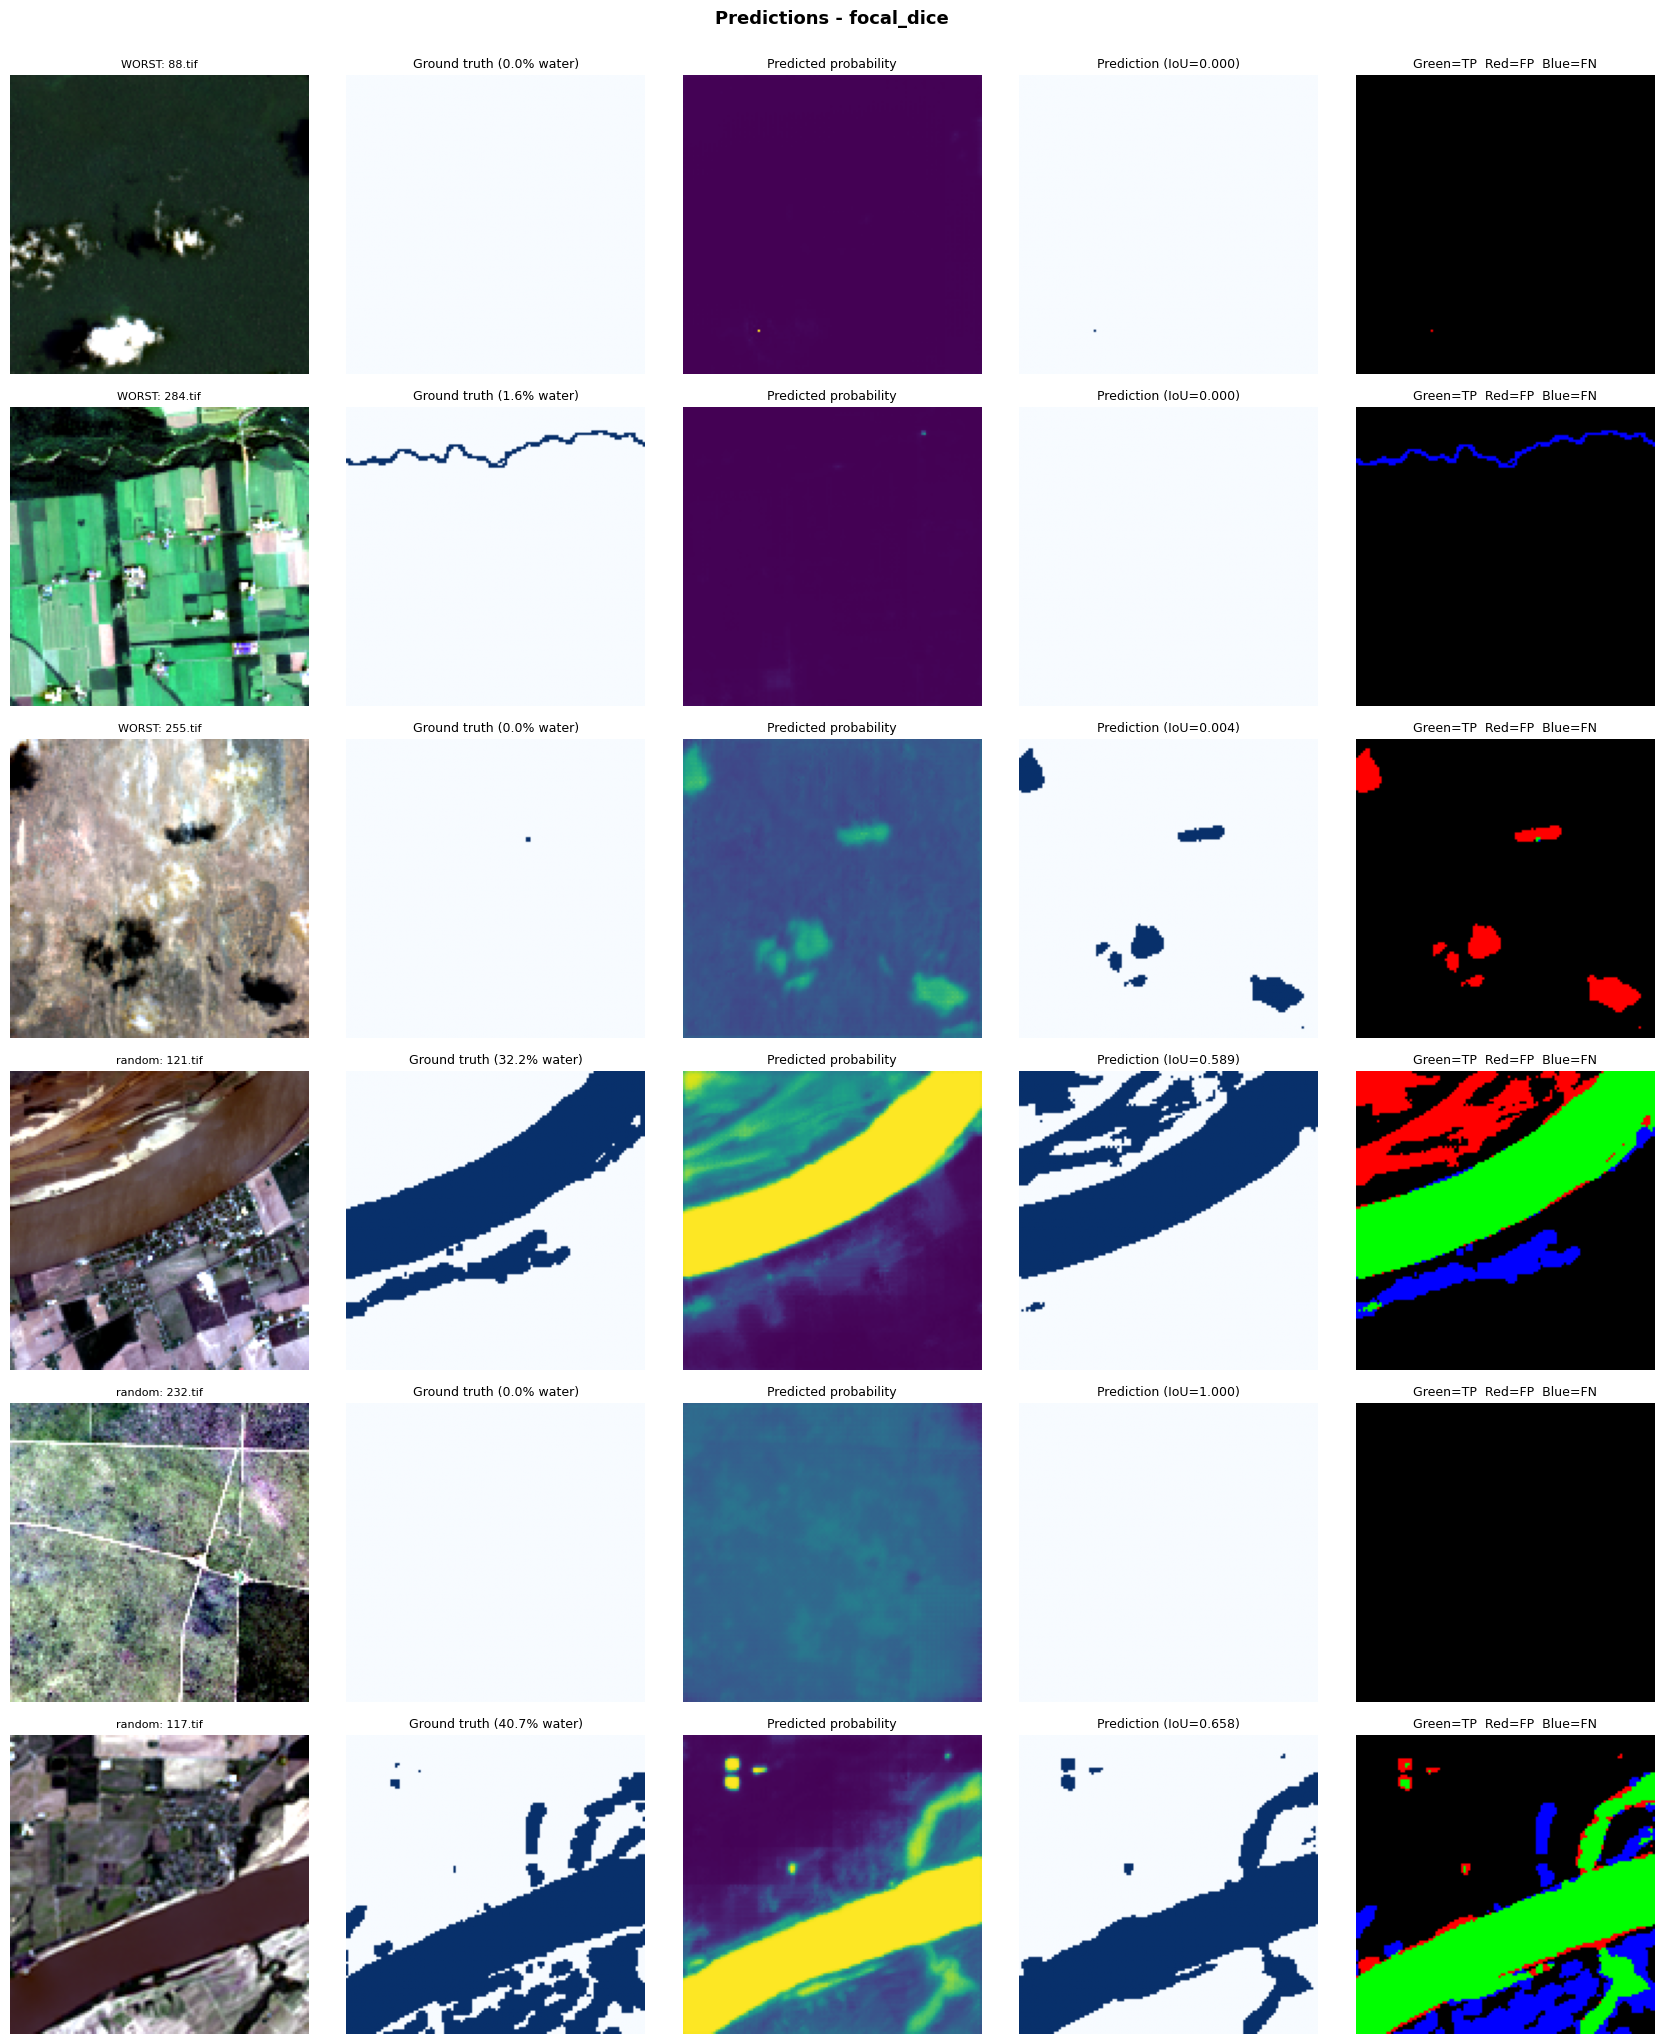

In [35]:
import csv

test_ds = test_loader_14.dataset                         # eval dataset (no augmentation), 14-ch

@torch.no_grad()
def predict_probs(model, ds, idxs):
    model.eval()
    xs = torch.stack([ds[i][0] for i in idxs]).to(device)
    return torch.sigmoid(model(xs)).cpu().numpy()[:, 0]  # (N,H,W) water probability

def get_gt(ds, i):
    return ds[i][1].numpy()[0] > 0.5

def get_rgb(ds, i):
    img = read_tif(os.path.join(ds.image_dir, ds.image_files[i]))
    return np.stack([norm_display(img[3]), norm_display(img[2]), norm_display(img[1])], -1)

def per_sample_iou(model, ds, bs=16):
    ious = []
    for s in range(0, len(ds), bs):
        idxs  = list(range(s, min(s + bs, len(ds))))
        preds = predict_probs(model, ds, idxs) > 0.5
        for p, i in zip(preds, idxs):
            g = get_gt(ds, i); union = (p | g).sum()
            ious.append(float((p & g).sum() / union) if union > 0 else 1.0)   # empty vs empty = perfect
    return np.array(ious)

def error_map(pred, gt):
    e = np.zeros((*pred.shape, 3))
    e[..., 1] = pred & gt          # green: true positive
    e[..., 0] = pred & ~gt         # red:   false positive
    e[..., 2] = ~pred & gt         # blue:  false negative (missed water)
    return e

def show_predictions(model, name, ds, n_worst=3, n_random=3, seed=0):
    ious  = per_sample_iou(model, ds)
    print(f"[{name}] test per-image IoU: mean={ious.mean():.3f}  median={np.median(ious):.3f}  "
          f"min={ious.min():.3f}  max={ious.max():.3f}")
    worst  = list(np.argsort(ious)[:n_worst])
    rest   = [i for i in range(len(ds)) if i not in worst]
    rng    = np.random.default_rng(seed)
    random_ = list(rng.choice(rest, size=min(n_random, len(rest)), replace=False))
    sel = worst + random_
    probs = predict_probs(model, ds, sel)

    fig, axes = plt.subplots(len(sel), 5, figsize=(17, 3.4 * len(sel)))
    axes = np.atleast_2d(axes)
    for r, (i, p) in enumerate(zip(sel, probs)):
        gt, pred = get_gt(ds, i), p > 0.5
        tag = "WORST" if i in worst else "random"
        axes[r, 0].imshow(get_rgb(ds, i));                 axes[r, 0].set_title(f"{tag}: {ds.image_files[i]}", fontsize=8)
        axes[r, 1].imshow(gt, cmap="Blues", vmin=0, vmax=1); axes[r, 1].set_title(f"Ground truth ({gt.mean()*100:.1f}% water)", fontsize=9)
        im = axes[r, 2].imshow(p, cmap="viridis", vmin=0, vmax=1); axes[r, 2].set_title("Predicted probability", fontsize=9)
        axes[r, 3].imshow(pred, cmap="Blues", vmin=0, vmax=1); axes[r, 3].set_title(f"Prediction (IoU={ious[i]:.3f})", fontsize=9)
        axes[r, 4].imshow(error_map(pred, gt));            axes[r, 4].set_title("Green=TP  Red=FP  Blue=FN", fontsize=9)
        for a in axes[r]: a.axis("off")
    fig.suptitle(f"Predictions - {name}", fontsize=13, fontweight="bold", y=1.0)
    plt.tight_layout(); plt.savefig(f"predictions_{name}.png", dpi=130, bbox_inches="tight"); plt.show()
    return ious

best_ious = show_predictions(exp_models[best_name], best_name, test_ds)

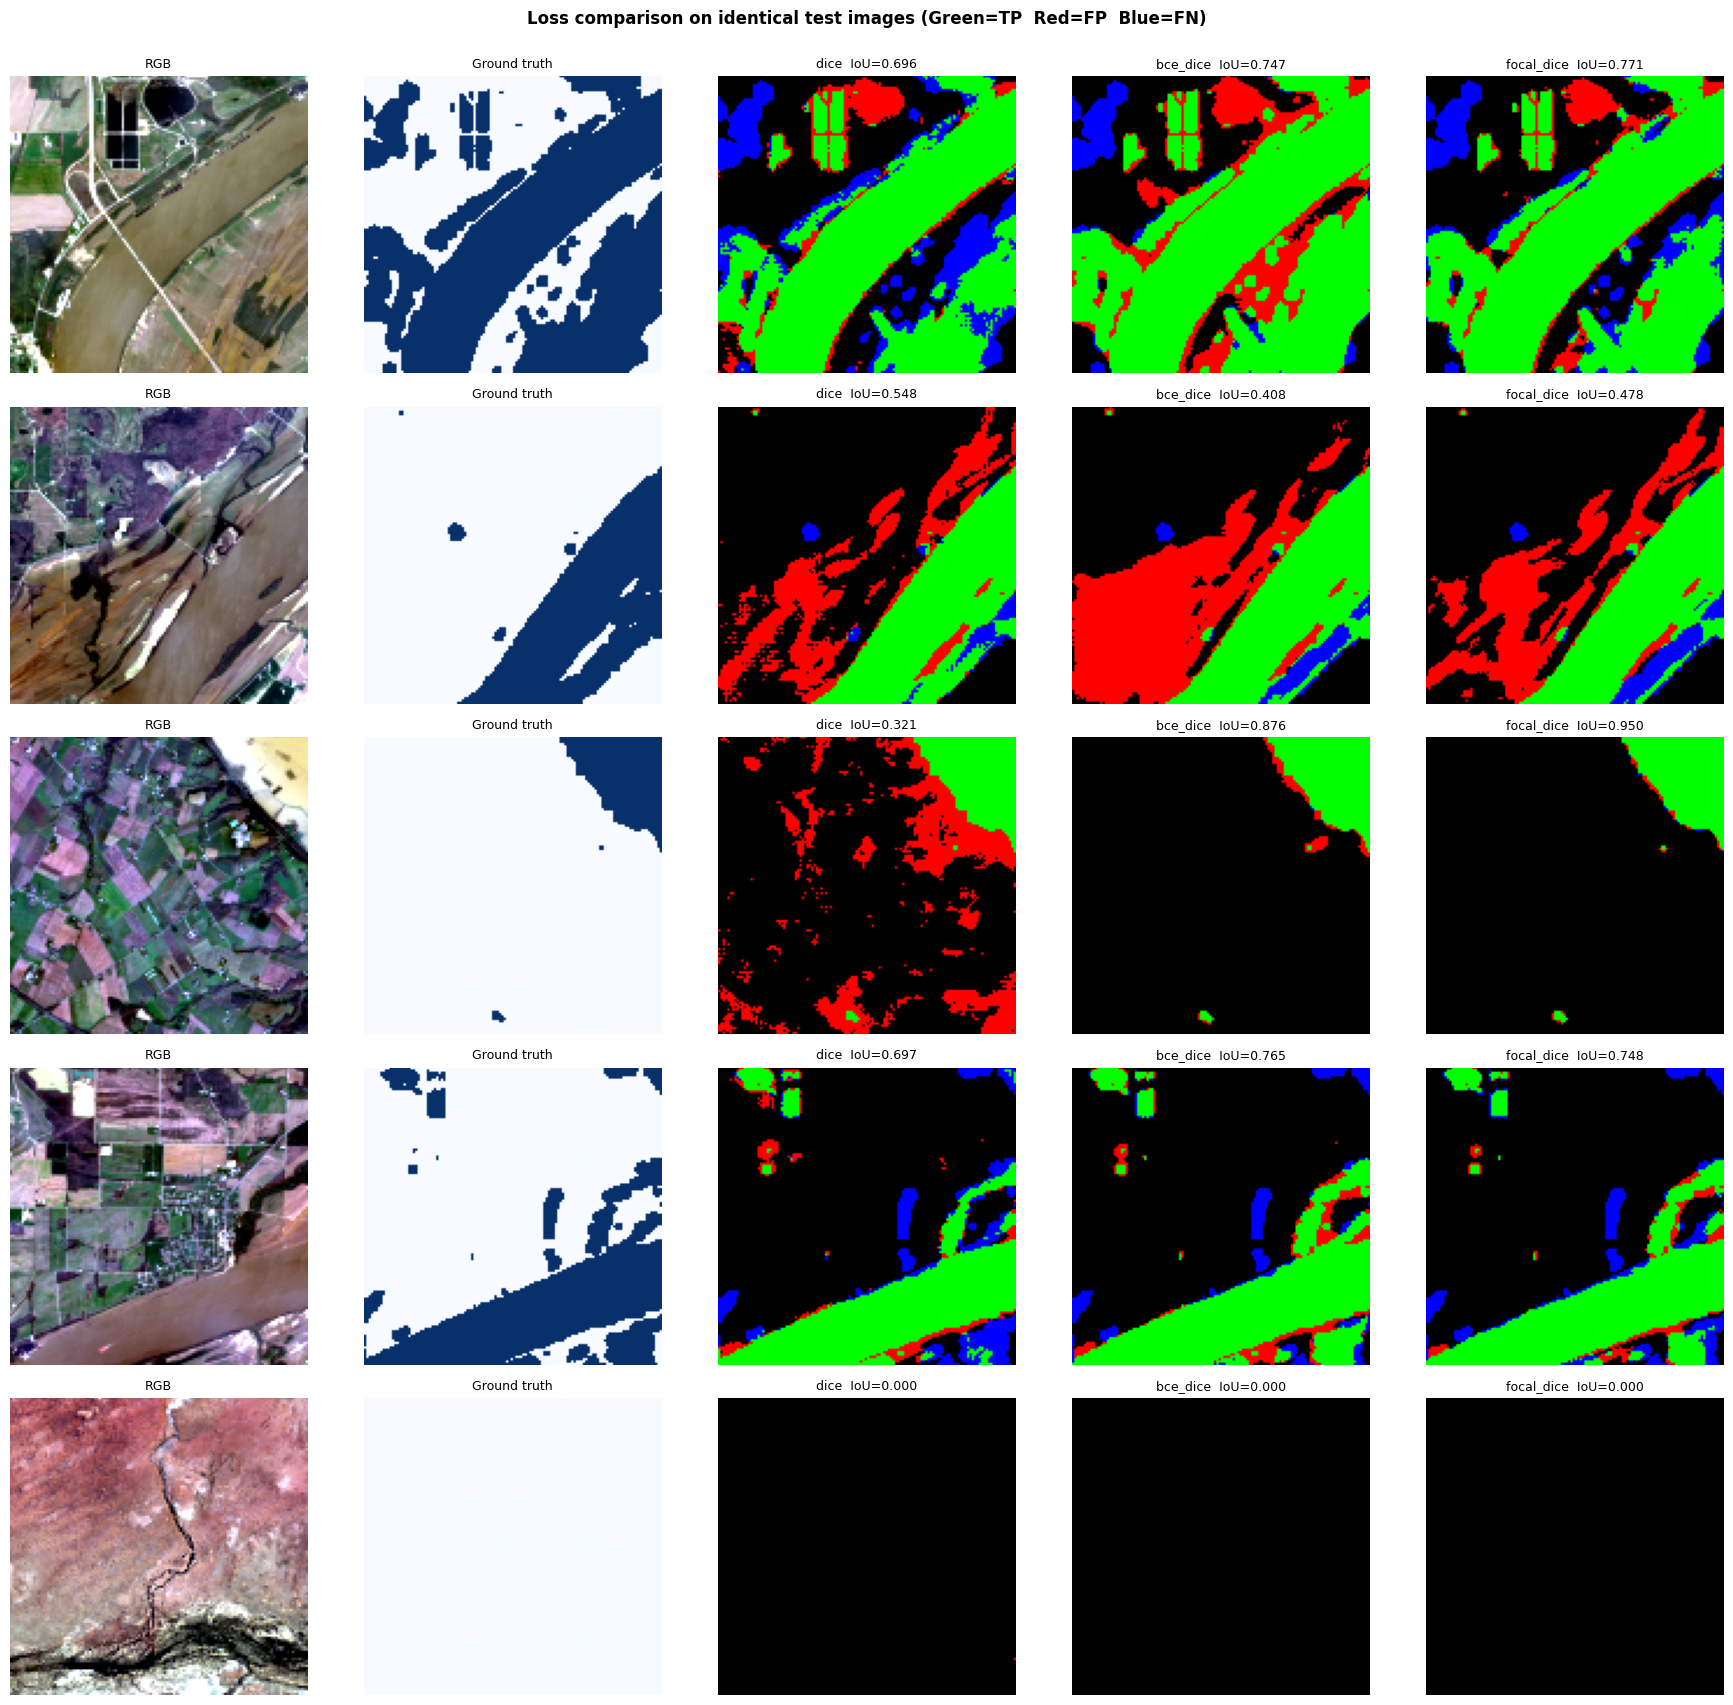

In [36]:
# ── Same test images, all loss variants side by side ─────────────────────────
rng = np.random.default_rng(1)
cmp_idx = list(rng.choice(len(test_ds), size=min(5, len(test_ds)), replace=False))
names   = list(exp_models)
probs   = {n: predict_probs(m, test_ds, cmp_idx) for n, m in exp_models.items()}

fig, axes = plt.subplots(len(cmp_idx), 2 + len(names), figsize=(3.6 * (2 + len(names)), 3.4 * len(cmp_idx)))
axes = np.atleast_2d(axes)
for r, i in enumerate(cmp_idx):
    gt = get_gt(test_ds, i)
    axes[r, 0].imshow(get_rgb(test_ds, i)); axes[r, 0].set_title("RGB", fontsize=9)
    axes[r, 1].imshow(gt, cmap="Blues", vmin=0, vmax=1); axes[r, 1].set_title("Ground truth", fontsize=9)
    for c, n in enumerate(names):
        pred = probs[n][r] > 0.5
        iou  = (pred & gt).sum() / max((pred | gt).sum(), 1)
        axes[r, 2 + c].imshow(error_map(pred, gt)); axes[r, 2 + c].set_title(f"{n}  IoU={iou:.3f}", fontsize=9)
    for a in axes[r]: a.axis("off")
fig.suptitle("Loss comparison on identical test images (Green=TP  Red=FP  Blue=FN)", fontsize=12, fontweight="bold", y=1.0)
plt.tight_layout(); plt.savefig("loss_comparison_predictions.png", dpi=130, bbox_inches="tight"); plt.show()

In [37]:
# ── Save predicted masks (0/255 PNG) + per-image IoU table for the best model ─
OUT_DIR = f"predictions/{best_name}"; os.makedirs(OUT_DIR, exist_ok=True)
rows = []
for s in range(0, len(test_ds), 16):
    idxs  = list(range(s, min(s + 16, len(test_ds))))
    preds = predict_probs(exp_models[best_name], test_ds, idxs) > 0.5
    for p, i in zip(preds, idxs):
        stem = os.path.splitext(test_ds.image_files[i])[0]
        Image.fromarray((p * 255).astype(np.uint8)).save(os.path.join(OUT_DIR, f"{stem}.png"))
        rows.append((stem, float(best_ious[i])))
with open(os.path.join(OUT_DIR, "per_image_iou.csv"), "w", newline="") as f:
    w = csv.writer(f); w.writerow(["image", "iou"]); w.writerows(rows)
print(f"Saved {len(rows)} predicted masks + per_image_iou.csv to {OUT_DIR}/")

Saved 32 predicted masks + per_image_iou.csv to predictions/focal_dice/
